# Count Objects in Image

The goal is to count the objects of one kind (cars, people, chairs) in a photo with a pre-trained object detector. The detector finds every object with a box, a class name and a confidence; counting is then counting the boxes of the wanted class.

Reference solution: [Count Objects in Image using Python](https://amanxai.com/2021/05/11/count-objects-in-image-using-python/) (Aman Kharwal). It uses the `cvlib` library (a YOLOv3 detector) on one photo of a motorway and prints the number of cars: 10.

The photo of the reference is in the material of the course (`cars.jpg`), and also introduces the YOLOv8 detector (`ultralytics`) and counts the detected classes with `value_counts`. This notebook uses that detector. The reference does not check its number against the number of cars a person sees, and it tests one photo with one setting; here seven photos with counts made by eye are used, and the effect of the confidence threshold and of the model size is measured.

In [3]:
#pip install ultralytics

In [4]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Computer Vision/count_objects_in_image')

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/mami/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


## Data Loading

Seven photos are used: the motorway photo of the reference (`cars.jpg`), three photos from various sources (`g8.jpg`, `dogs.jpg`, `kitchen.jpeg`) and two sample photos delivered with `ultralytics` (`bus.jpg`, `zidane.jpg`). The objects were counted by eye to get a ground truth:

- `cars.jpg`: 11 cars are fully or mostly visible (a twelfth is cut by the corner of the image and is not counted).
- `g8.jpg`: 6 people. `dogs.jpg`: 4 dogs. `kitchen.jpeg`: 4 chairs.
- `bus.jpg`: 1 bus and 4 people (two of them are cut by the border of the image).
- `zidane.jpg`: 2 people and 2 ties (the crowd in the background is blurred and not counted).

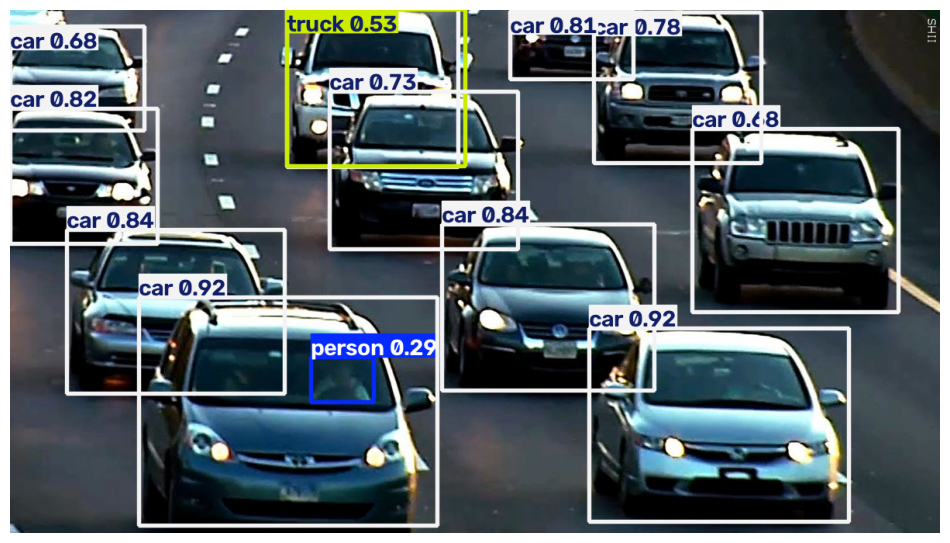

In [5]:
truth = pd.DataFrame([
    ("cars.jpg", "car", 11), ("cars.jpg", "car+truck+bus", 11), ("g8.jpg", "person", 6), ("dogs.jpg", "dog", 4),
    ("kitchen.jpeg", "chair", 4), ("bus.jpg", "person", 4), ("bus.jpg", "bus", 1), ("zidane.jpg", "person", 2), ("zidane.jpg", "tie", 2),
], columns=["image", "target", "truth"])

model = YOLO("yolov8n.pt")
result = model("images/cars.jpg", verbose=False)[0]

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## Detection and Counting

Every detected box has a class name. The number of boxes of each class in the motorway photo (default confidence threshold of 0.25):

In [6]:
def counts(model, image, conf=0.25):
    boxes = model(f"images/{image}", conf=conf, verbose=False)[0].boxes
    return pd.Series([model.names[int(c)] for c in boxes.cls], dtype=str).value_counts()

counts(model, "cars.jpg")

car       11
truck      1
person     1
Name: count, dtype: int64

The detector finds 11 cars, which is the number counted by eye, and the reference found 10. It also finds one truck (probably the vehicle cut by the corner of the image) and a person that is not there. The kind of vehicle matters: a detector can call a large SUV a `truck`, so counting only the class `car` can miss vehicles that a reader would count. The target `car+truck+bus` adds the three classes.

## Evaluation

The predicted counts are compared with the counts by eye for the nine (image, class) pairs. Three model sizes of the same detector (nano, small and medium; the small and the medium weights are downloaded by `ultralytics` at the first use) and four confidence thresholds are compared, with the mean absolute error of the counts and the number of exact counts out of nine.

In [7]:
def predicted(model, conf):
    per_image = {image: counts(model, image, conf) for image in truth["image"].unique()}
    return np.array([per_image[row.image].reindex(row.target.split("+"), fill_value=0).sum() for row in truth.itertuples()])

models = {"nano": model, "small": YOLO("yolov8s.pt"), "medium": YOLO("yolov8m.pt")}
grid = {(name, conf): predicted(m, conf) for name, m in models.items() for conf in [0.1, 0.25, 0.5, 0.7]}

pd.DataFrame({key: {"mean absolute error": np.abs(p - truth["truth"]).mean(), "exact counts (of 9)": int((p == truth["truth"]).sum())}
              for key, p in grid.items()}).T.round(2)

mean absolute error  exact counts (of 9)
nano   0.10                 2.00                  4.0
       0.25                 0.44                  6.0
       0.50                 0.56                  5.0
       0.70                 1.11                  4.0
small  0.10                 1.11                  3.0
       0.25                 0.22                  7.0
       0.50                 0.22                  7.0
       0.70                 1.00                  5.0
medium 0.10                 0.67                  4.0
       0.25                 0.22                  7.0
       0.50                 0.22                  7.0
       0.70                 1.00                  6.0

In [8]:
truth_table = truth.assign(**{"nano, 0.25": grid[("nano", 0.25)], "small, 0.25": grid[("small", 0.25)], "medium, 0.25": grid[("medium", 0.25)]})
truth_table

,image,target,truth,"nano, 0.25","small, 0.25","medium, 0.25"
0,cars.jpg,car,11,11,11,11
1,cars.jpg,car+truck+bus,11,12,12,11
2,g8.jpg,person,6,6,6,6
3,dogs.jpg,dog,4,4,4,4
4,kitchen.jpeg,chair,4,6,4,5
5,bus.jpg,person,4,4,4,4
6,bus.jpg,bus,1,1,1,1
7,zidane.jpg,person,2,2,2,3
8,zidane.jpg,tie,2,1,1,2


## Counting with Classical Image Processing

Counting also works without a neural network when the objects are simple. The photo `bunchofshapes.jpg` has coloured shapes on a white background. The image is turned into black and white, the outlines of the white-on-black regions are found (`cv2.findContours`), and the number of corners of each outline (`cv2.approxPolyDP`) tells the shape.

In [9]:
gray = cv2.imread("images/bunchofshapes.jpg", 0)
_, binary = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
shapes = [c for c in contours if cv2.contourArea(c) > 500]

corner_names = {3: "triangle", 4: "rectangle"}
kinds = [corner_names.get(len(cv2.approxPolyDP(c, 0.03 * cv2.arcLength(c, True), True)), "circle") for c in shapes]
print("shapes counted:", len(shapes), "|", kinds)

cars_gray = cv2.imread("images/cars.jpg", 0)
_, cars_binary = cv2.threshold(cars_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
cars_contours, _ = cv2.findContours(cars_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print("regions found by the same method in the motorway photo:", len([c for c in cars_contours if cv2.contourArea(c) > 500]), "(the photo has 11 cars)")

shapes counted: 4 | ['rectangle', 'triangle', 'circle', 'rectangle']
regions found by the same method in the motorway photo: 16 (the photo has 11 cars)


The confidence threshold has a large effect, so a single number from a single setting says little. With a very low threshold (0.10) the detectors report many false objects and the counts are too high (mean absolute error 2.0 for the nano model, 1.1 for the small one). With a very high threshold (0.70) real objects are missed (error about 1.0). The best results are around the default of 0.25 to 0.5: the small and the medium models have a mean absolute error of 0.22 and count 7 of the 9 targets exactly, the nano model has an error of 0.44 and counts 6 exactly.

The remaining errors show the typical weaknesses of counting with a detector. The nano model counts 6 chairs instead of 4 in the kitchen photo, the medium model 5, and only the small model gets it right; the medium model finds a third person in the Zidane photo where two are clearly visible, while the two smaller models miss one of the two ties. In the motorway photo, the class `car` gives 11, the number counted by eye, while `car+truck+bus` gives 12 for the nano and small models: the additional truck is probably the vehicle that is cut by the corner of the image, which was not counted by eye.

Classical image processing counts the four shapes of the drawing correctly (two rectangles, a triangle and a circle), because the shapes are uniform and the background is white. The same method finds 16 regions in the motorway photo where a person sees 11 cars: light, shadows and reflections make it impossible to separate the objects with a simple threshold, which is the reason to use a detector for real photos.

## Conclusion

**Reference approach.** The reference uses the `cvlib` library (a YOLOv3 detector) on one motorway photo and prints "Number of cars in this image are 10". It counts the class `car` only, tests one photo with one setting, and compares the number with nothing. Some readers could not run it (missing model files, environment problems), and it depends on an old detector.

**Our approach.** The YOLOv8 detector was applied to the same photo and to six other photos with counts made by eye (nine image and class pairs). On the motorway photo, the class `car` gives 11, which is the number counted by eye (the reference reports 10). The counts were compared for three model sizes and four confidence thresholds:

| Model | Threshold 0.10 | 0.25 | 0.50 | 0.70 |
|---|---|---|---|---|
| Nano (mean absolute error of the count) | 2.00 | 0.44 | 0.56 | 1.11 |
| Small | 1.11 | 0.22 | 0.22 | 1.00 |
| Medium | 0.67 | 0.22 | 0.22 | 1.00 |

The small and the medium models count 7 of the 9 targets exactly at a threshold of 0.25 or 0.5, the nano model 6 (at 0.25). A threshold that is too low adds false objects and one that is too high removes real ones, so the threshold has to be chosen on photos with known counts. Counting the class `car` and counting all vehicles (`car`, `truck`, `bus`) can give different results (11 and 12 for the nano model), so the definition of what is counted matters. Classical image processing (threshold and contours) counts four simple shapes on a white background exactly, but finds 16 regions in the motorway photo that has 11 cars.

**Limitations.** The ground truth was counted by eye by the author of this notebook, and some cases are ambiguous (objects cut by the border of the image, a blurred crowd). Only seven photos and nine targets were used, so the error values are rough and their differences (0.22 against 0.44) can change with other photos. The reference could not be reproduced with the same library (`cvlib` and YOLOv3), so its number is the one printed in the article. A detector counts what it sees; heavily overlapping objects (a crowd, stacked items) are counted less reliably.